<a href="https://colab.research.google.com/github/angelica-gregorio/data102-s30a/blob/main/GREGORIO_Notebook12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Processing
Submitted by: GREGORIO, Angelica G.
---


# 1. Setup
---

## Install Necessary Libraries

In [1]:
# Install required packages (run once)
!pip install networkx pandas numpy matplotlib seaborn gensim node2vec scikit-learn --quiet

## Import the Libraries

In [2]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings

from gensim.models import Word2Vec
from node2vec import Node2Vec as N2V
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.patches import Patch

random.seed(42)
np.random.seed(42)
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


# 2. Data Ingestion

In [5]:
#Loading the CSV files
nodes_df = pd.read_csv('nodes.csv')
edges_df = pd.read_csv('edges.csv')

In [6]:
print("NODES (first 5):")
print(nodes_df.head())
print(f"\nEDGES (first 5):")
print(edges_df.head())
print(f"\nTotal: {len(nodes_df)} nodes, {len(edges_df)} edges")

NODES (first 5):
  node_id          name                   major     student_group  year_level
0     E01    Ana Rivera            Data Science   Statistics Club           2
1     E02    Ben Carter        Computer Science  Robotics Society           4
2     E03   Chloe Singh      Business Analytics   Student Council           3
3     E04  Diego Santos  Industrial Engineering   Operations Club           4
4     E05    Emma Walsh              Psychology      Peer Mentors           2

EDGES (first 5):
  source target  weight         relationship_type
0    E01    E02       8   strong_study_connection
1    E01    E03       6  regular_class_connection
2    E01    E04       7   strong_study_connection
3    E01    E05       5  regular_class_connection
4    E01    E06       4   light_campus_connection

Total: 15 nodes, 105 edges


In [10]:
#Building the NetworkX Graph
G = nx.Graph()

for _, row in nodes_df.iterrows():
    G.add_node(int(row['node_id'][1:]), # Extract numeric part '01' from 'E01' and convert to int
               name=row['name'],
               major=row['major'],
               student_group=row['student_group'],
               year_level=row['year_level'])

for _, row in edges_df.iterrows():
    G.add_edge(int(row['source'][1:]), # Extract numeric part '01' from 'E01' and convert to int
               int(row['target'][1:]), # Extract numeric part '02' from 'E02' and convert to int
               weight=row['weight'],
               relationship_type=row['relationship_type'])

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Directed: {G.is_directed()} | Weighted: {nx.is_weighted(G)}")
print(f"\nNeighbors of Ana Rivera (node 1): {list(G.neighbors(1))}") # Corrected name
print(f"Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

Graph built: 15 nodes, 105 edges
Directed: False | Weighted: True

Neighbors of Ana Rivera (node 1): [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Average degree: 14.00


# 3. Network Visualization

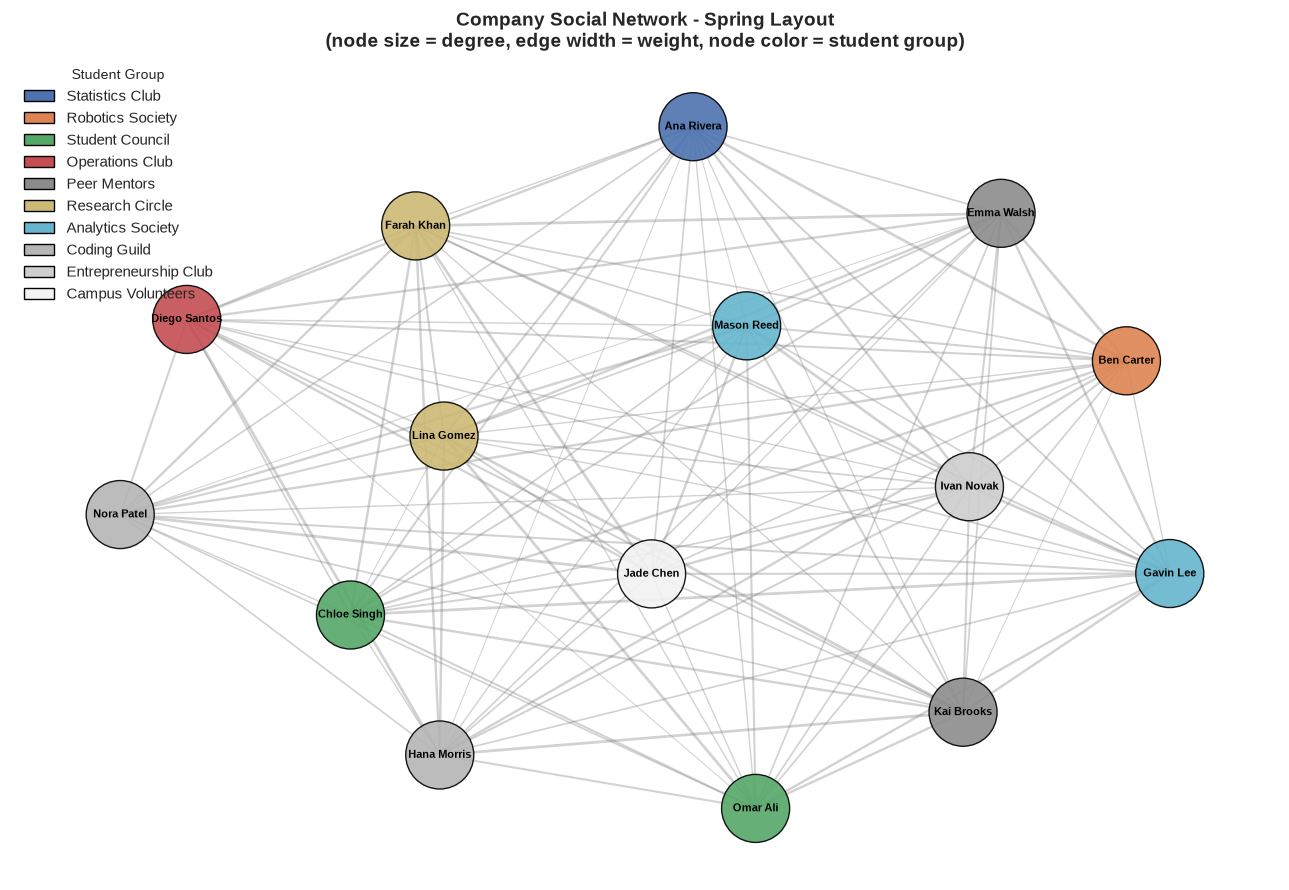

Saved: network_spring_layout.png


In [11]:
student_group_colors = {
    'Statistics Club':      '#4C72B0',
    'Robotics Society':     '#DD8452',
    'Student Council':      '#55A868',
    'Operations Club':      '#C44E52',
    'Peer Mentors':         '#8C8C8C',
    'Research Circle':      '#CCB974',
    'Analytics Society':    '#64B5CD',
    'Coding Guild':         '#B5B5B5',
    'Entrepreneurship Club':'#CECECE',
    'Campus Volunteers':    '#F2F2F2'
}

node_colors   = [student_group_colors[G.nodes[n]['student_group']] for n in G.nodes()]
node_sizes    = [300 + 150 * G.degree(n) for n in G.nodes()]
labels        = {n: G.nodes[n]['name'] for n in G.nodes()}
edge_weights  = [G[u][v]['weight'] / 4 for u, v in G.edges()]
legend_elements = [Patch(facecolor=c, edgecolor='black', label=d)
                   for d, c in student_group_colors.items()]

# Plot 1: Spring layout
pos_spring = nx.spring_layout(G, k=1.5, seed=42)

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_edges(G, pos_spring, width=edge_weights, alpha=0.35,
                       edge_color='gray', ax=ax)
nx.draw_networkx_nodes(G, pos_spring, node_color=node_colors,
                       node_size=node_sizes, edgecolors='black',
                       linewidths=1, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos_spring, labels, font_size=8,
                        font_weight='bold', ax=ax)

ax.legend(handles=legend_elements, loc='upper left', fontsize=11, title='Student Group')
ax.set_title('Company Social Network - Spring Layout\n(node size = degree, edge width = weight, node color = student group)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('network_spring_layout.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: network_spring_layout.png")

# 4. Graph Representations

In [12]:
#Adjacency List
print("ADJACENCY LIST REPRESENTATION")
print("=" * 55)
print(f"{'Node':<10} {'Neighbors'}")
print("-" * 55)

for node in sorted(G.nodes()):
    name = G.nodes[node]['name']
    neighbor_names = [G.nodes[n]['name'] for n in sorted(G.neighbors(node))]
    print(f"  {name:<10} -> {', '.join(neighbor_names)}")

print(f"\nCompact: only {G.number_of_edges()} edges stored vs "
      f"{G.number_of_nodes()}² = {G.number_of_nodes()**2} matrix cells")

# Export to .adjlist (node IDs)
nx.write_adjlist(G, 'network.adjlist')
print("\n[EXPORTED] Adjacency list  -> network.adjlist")

# Also export a human-readable version with names
with open('network_named.adjlist', 'w') as f:
    f.write("# Adjacency list - node names\n")
    for node in sorted(G.nodes()):
        name = G.nodes[node]['name']
        neighbor_names = [G.nodes[n]['name'] for n in sorted(G.neighbors(node))]
        f.write(f"{name}: {', '.join(neighbor_names)}\n")
print("[EXPORTED] Named adjacency list -> network_named.adjlist")

ADJACENCY LIST REPRESENTATION
Node       Neighbors
-------------------------------------------------------
  Ana Rivera -> Ben Carter, Chloe Singh, Diego Santos, Emma Walsh, Farah Khan, Gavin Lee, Hana Morris, Ivan Novak, Jade Chen, Kai Brooks, Lina Gomez, Mason Reed, Nora Patel, Omar Ali
  Ben Carter -> Ana Rivera, Chloe Singh, Diego Santos, Emma Walsh, Farah Khan, Gavin Lee, Hana Morris, Ivan Novak, Jade Chen, Kai Brooks, Lina Gomez, Mason Reed, Nora Patel, Omar Ali
  Chloe Singh -> Ana Rivera, Ben Carter, Diego Santos, Emma Walsh, Farah Khan, Gavin Lee, Hana Morris, Ivan Novak, Jade Chen, Kai Brooks, Lina Gomez, Mason Reed, Nora Patel, Omar Ali
  Diego Santos -> Ana Rivera, Ben Carter, Chloe Singh, Emma Walsh, Farah Khan, Gavin Lee, Hana Morris, Ivan Novak, Jade Chen, Kai Brooks, Lina Gomez, Mason Reed, Nora Patel, Omar Ali
  Emma Walsh -> Ana Rivera, Ben Carter, Chloe Singh, Diego Santos, Farah Khan, Gavin Lee, Hana Morris, Ivan Novak, Jade Chen, Kai Brooks, Lina Gomez, Mason Reed,

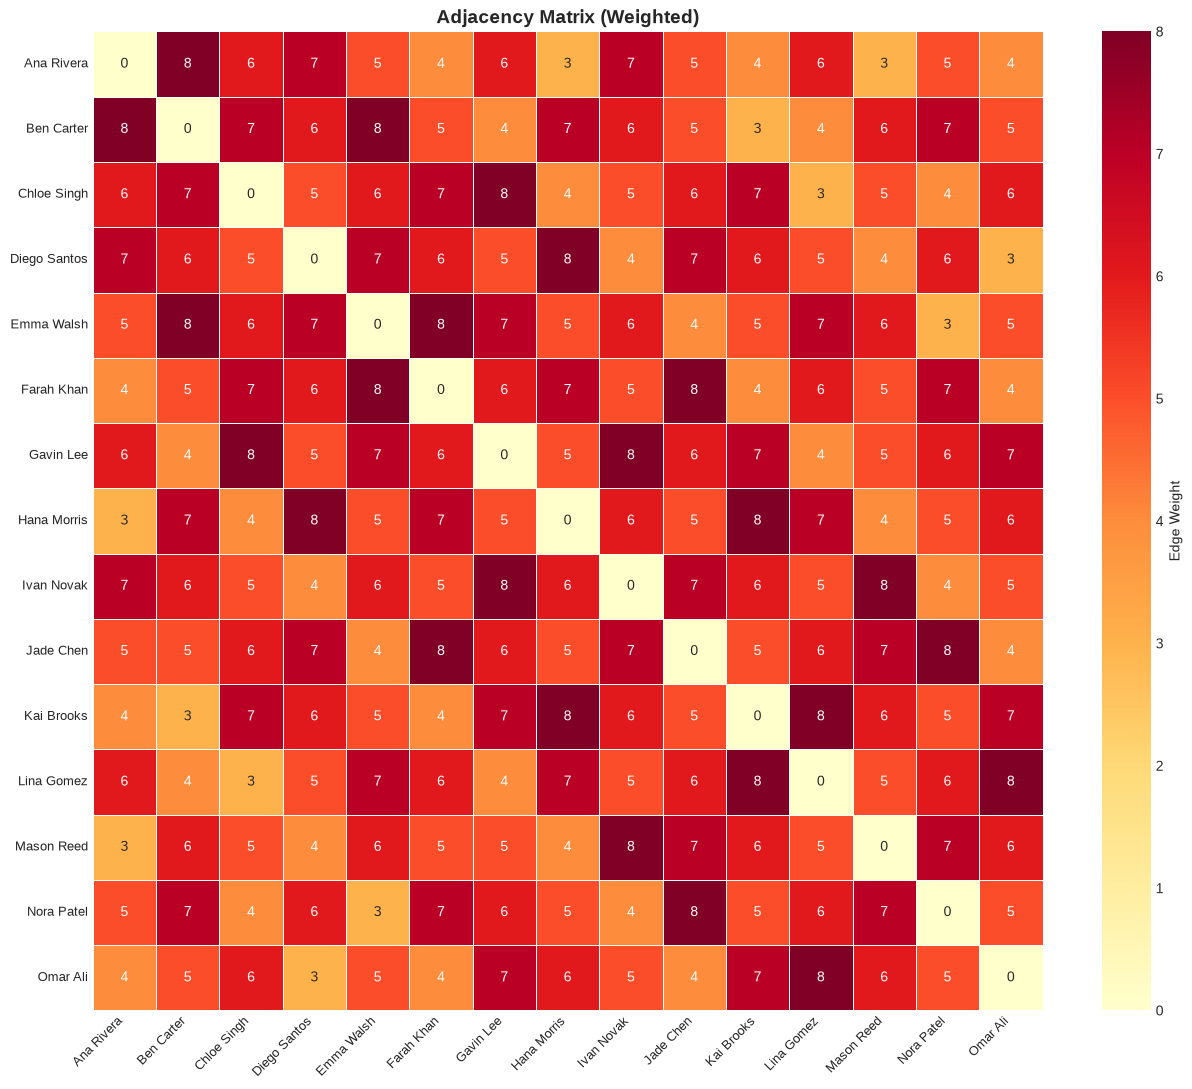

Matrix size : 15x15 = 225 cells
Non-zero entries : 210
Sparsity     : 6.7%

[EXPORTED] Adjacency matrix -> adjacency_matrix.csv


In [15]:
node_list_sorted = sorted(G.nodes())
node_labels_sorted = [G.nodes[n]['name'] for n in node_list_sorted]

adj_matrix = nx.to_numpy_array(G, nodelist=node_list_sorted)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(adj_matrix,
            xticklabels=node_labels_sorted,
            yticklabels=node_labels_sorted,
            cmap='YlOrRd', annot=True, fmt='g',
            linewidths=0.5,
            cbar_kws={'label': 'Edge Weight'},
            ax=ax)
ax.set_title('Adjacency Matrix (Weighted)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('adjacency_matrix_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

non_zero = int(np.count_nonzero(adj_matrix))
print(f"Matrix size : {adj_matrix.shape[0]}x{adj_matrix.shape[1]} = {adj_matrix.shape[0]**2} cells")
print(f"Non-zero entries : {non_zero}")
print(f"Sparsity     : {1 - non_zero / adj_matrix.size:.1%}")

# Export adjacency matrix to CSV
adj_df = pd.DataFrame(adj_matrix,
                       index=node_labels_sorted,
                       columns=node_labels_sorted)
adj_df.to_csv('adjacency_matrix.csv')
print("\n[EXPORTED] Adjacency matrix -> adjacency_matrix.csv")

# 5. Deepwalk

In [19]:
#Modular funtions for reusability later in tweaking the parameters
def generate_random_walks(graph, num_walks, walk_length, seed=42):
    # Generate uniform random walks from every node
    random.seed(seed)
    walks = []
    nodes = list(graph.nodes())
    for _ in range(num_walks):
        random.shuffle(nodes)
        for start in nodes:
            walk = [start]
            current = start
            for _ in range(walk_length - 1):
                nbrs = list(graph.neighbors(current))
                if not nbrs:
                    break
                current = random.choice(nbrs)
                walk.append(current)
            walks.append([str(n) for n in walk])  # Word2Vec expects strings
    return walks


def train_deepwalk(graph, num_walks, walk_length, vector_size, window, epochs,
                   label="DeepWalk"):
    #Full DeepWalk pipeline: walks → Word2Vec → embeddings dict
    print(f"[{label}] Generating {num_walks} walks of length {walk_length}...")
    walks = generate_random_walks(graph, num_walks, walk_length)

    print(f"[{label}] Training Word2Vec: dim={vector_size}, window={window}, epochs={epochs}")
    model = Word2Vec(sentences=walks, vector_size=vector_size, window=window,
                     min_count=1, sg=1, workers=1, epochs=epochs, seed=42)

    embeddings = {n: model.wv[str(n)] for n in graph.nodes()}
    print(f"[{label}] Done.\n")
    return embeddings, model


def tsne_project(embeddings, nodes_list, random_state=42):
    #Reduce embeddings to 2D with t-SNE.
    matrix = np.array([embeddings[n] for n in nodes_list])
    perplexity = min(5, len(nodes_list) - 1)
    return TSNE(n_components=2, random_state=random_state,
                perplexity=perplexity).fit_transform(matrix)


def plot_embedding(ax, coords_2d, nodes_list, graph, group_colors, title):
    #Scatter-plot a 2D embedding coloured by student group.
    for group, color in group_colors.items():
        idx = [i for i, n in enumerate(nodes_list)
               if graph.nodes[n]['student_group'] == group] # Changed to 'student_group'
        ax.scatter(coords_2d[idx, 0], coords_2d[idx, 1],
                   c=color, label=group, s=180,
                   edgecolors='black', linewidths=0.8, alpha=0.85)
    for i, node in enumerate(nodes_list):
        ax.annotate(graph.nodes[node]['name'],
                    (coords_2d[i, 0], coords_2d[i, 1]),
                    fontsize=8, ha='center', va='bottom',
                    xytext=(0, 7), textcoords='offset points')
    ax.legend(title='Student Group', fontsize=9, loc='best') # Changed title to 'Student Group'
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE Dim 1'); ax.set_ylabel('t-SNE Dim 2')


nodes_list = sorted(G.nodes())
print("Helper functions defined. Ready to run DeepWalk experiments.")

Helper functions defined. Ready to run DeepWalk experiments.


### DeepWalk — Parameter Set 1


**Configuration:**
- `num_walks = 10`, `walk_length = 10`
- `vector_size = 32`, `window = 5`, `epochs = 5`


[DW Set 1] Generating 10 walks of length 10...
[DW Set 1] Training Word2Vec: dim=32, window=5, epochs=5
[DW Set 1] Done.



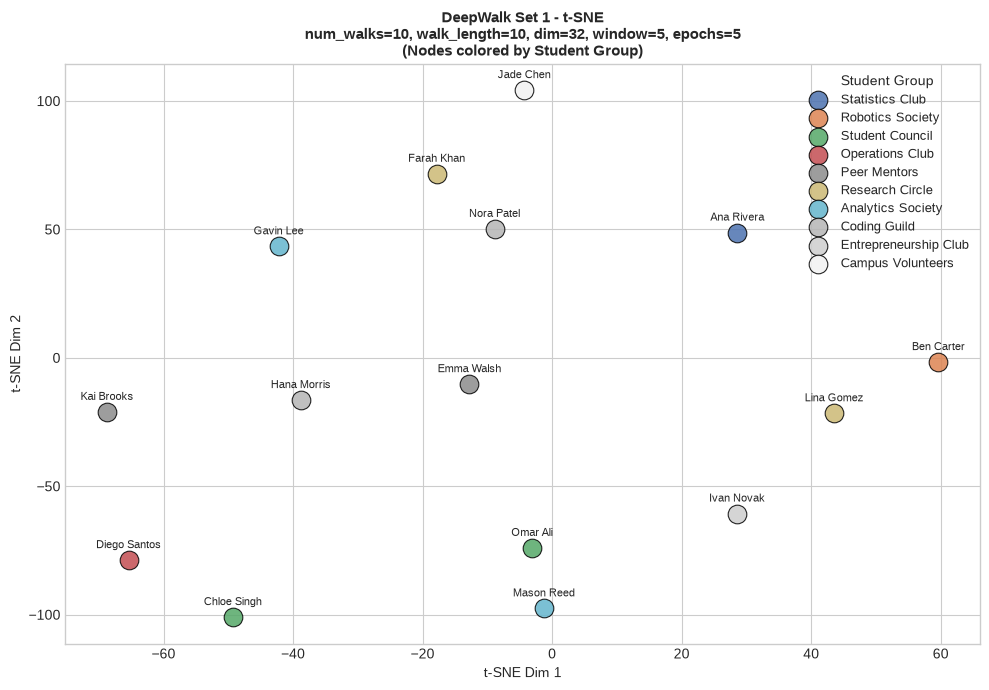

Most similar to Ana Rivera (Set 1):
  Farah Khan (Biology) - 0.553
  Jade Chen  (Industrial Engineering) - 0.553
  Diego Santos (Industrial Engineering) - 0.516
  Omar Ali   (Business Analytics) - 0.511
  Chloe Singh (Business Analytics) - 0.499


In [20]:
# DeepWalk Set 1
DW_PARAMS_1 = dict(num_walks=10, walk_length=10,
                   vector_size=32, window=5, epochs=5)

dw_emb_1, dw_model_1 = train_deepwalk(G, label="DW Set 1", **DW_PARAMS_1)
dw_2d_1 = tsne_project(dw_emb_1, nodes_list)

fig, ax = plt.subplots(figsize=(10, 7))

# Custom plotting logic adapted for student_group
# Scatter-plot the 2D embedding coloured by student group.
for group, color in student_group_colors.items():
    idx = [i for i, n in enumerate(nodes_list)
           if G.nodes[n]['student_group'] == group]
    ax.scatter(dw_2d_1[idx, 0], dw_2d_1[idx, 1],
               c=color, label=group, s=180,
               edgecolors='black', linewidths=0.8, alpha=0.85)
for i, node in enumerate(nodes_list):
    ax.annotate(G.nodes[node]['name'],
                (dw_2d_1[i, 0], dw_2d_1[i, 1]),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 7), textcoords='offset points')
ax.legend(title='Student Group', fontsize=9, loc='best')
ax.set_title("DeepWalk Set 1 - t-SNE\n"
             f"num_walks={DW_PARAMS_1['num_walks']}, walk_length={DW_PARAMS_1['walk_length']}, "
             f"dim={DW_PARAMS_1['vector_size']}, window={DW_PARAMS_1['window']}, "
             f"epochs={DW_PARAMS_1['epochs']}\n"
             "(Nodes colored by Student Group)", fontsize=11, fontweight='bold')
ax.set_xlabel('t-SNE Dim 1'); ax.set_ylabel('t-SNE Dim 2')

plt.tight_layout()
plt.savefig('deepwalk_set1.png', dpi=120, bbox_inches='tight')
plt.show()

print("Most similar to Ana Rivera (Set 1):")
for nid, sim in dw_model_1.wv.most_similar('1', topn=5):
    print(f"  {G.nodes[int(nid)]['name']:<10} ({G.nodes[int(nid)]['major']}) - {sim:.3f}")


### DeepWalk — Parameter Set 2

**Configuration:**
- `num_walks = 80`, `walk_length = 40`
- `vector_size = 128`, `window = 15`, `epochs = 20`


[DW Set 2] Generating 80 walks of length 40...
[DW Set 2] Training Word2Vec: dim=128, window=15, epochs=20
[DW Set 2] Done.



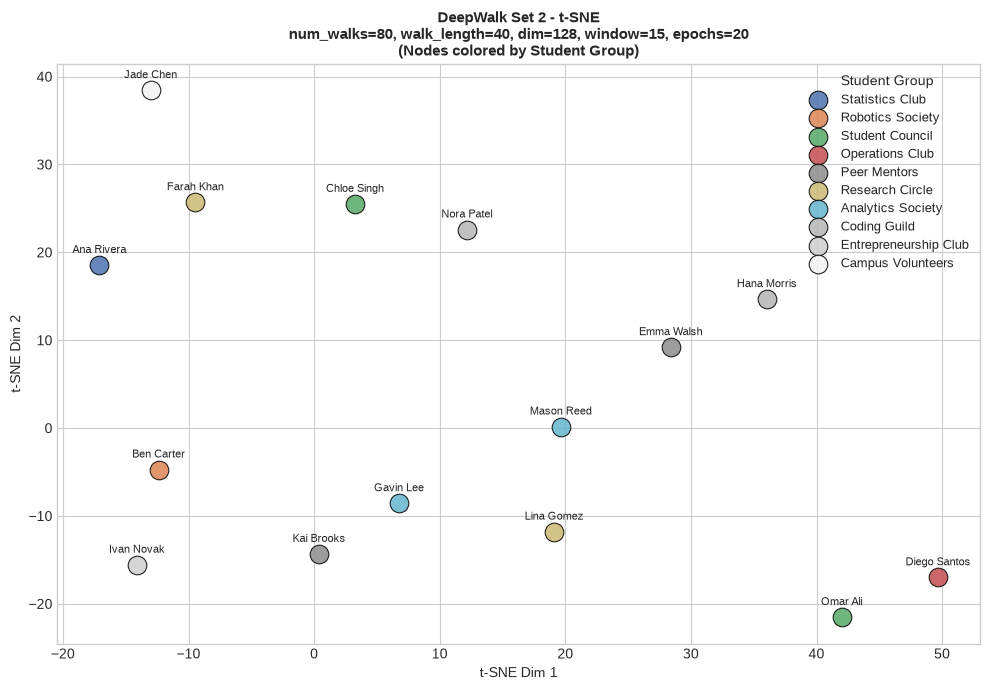

Most similar to Ana Rivera (Set 2):
  Farah Khan (Biology) - 0.980
  Ivan Novak (Business Analytics) - 0.960
  Ben Carter (Computer Science) - 0.958
  Chloe Singh (Business Analytics) - 0.952
  Kai Brooks (Psychology) - 0.940


In [23]:
DW_PARAMS_2 = dict(num_walks=80, walk_length=40,
                   vector_size=128, window=15, epochs=20)

dw_emb_2, dw_model_2 = train_deepwalk(G, label="DW Set 2", **DW_PARAMS_2)
dw_2d_2 = tsne_project(dw_emb_2, nodes_list)

fig, ax = plt.subplots(figsize=(10, 7))
plot_embedding(ax, dw_2d_2, nodes_list, G, student_group_colors,
               "DeepWalk Set 2 - t-SNE\n"
               f"num_walks={DW_PARAMS_2['num_walks']}, walk_length={DW_PARAMS_2['walk_length']}, "
               f"dim={DW_PARAMS_2['vector_size']}, window={DW_PARAMS_2['window']}, "
               f"epochs={DW_PARAMS_2['epochs']}\n"
               "(Nodes colored by Student Group)")
plt.tight_layout()
plt.savefig('deepwalk_set2.png', dpi=120, bbox_inches='tight')
plt.show()

print("Most similar to Ana Rivera (Set 2):")
for nid, sim in dw_model_2.wv.most_similar('1', topn=5):
    print(f"  {G.nodes[int(nid)]['name']:<10} ({G.nodes[int(nid)]['major']}) - {sim:.3f}")


### DeepWalk — Parameter Set 3

**Configuration:**
- `num_walks = 40`, `walk_length = 20`
- `vector_size = 64`, `window = 10`, `epochs = 10`

[DW Set 3] Generating 40 walks of length 20...
[DW Set 3] Training Word2Vec: dim=64, window=10, epochs=10
[DW Set 3] Done.



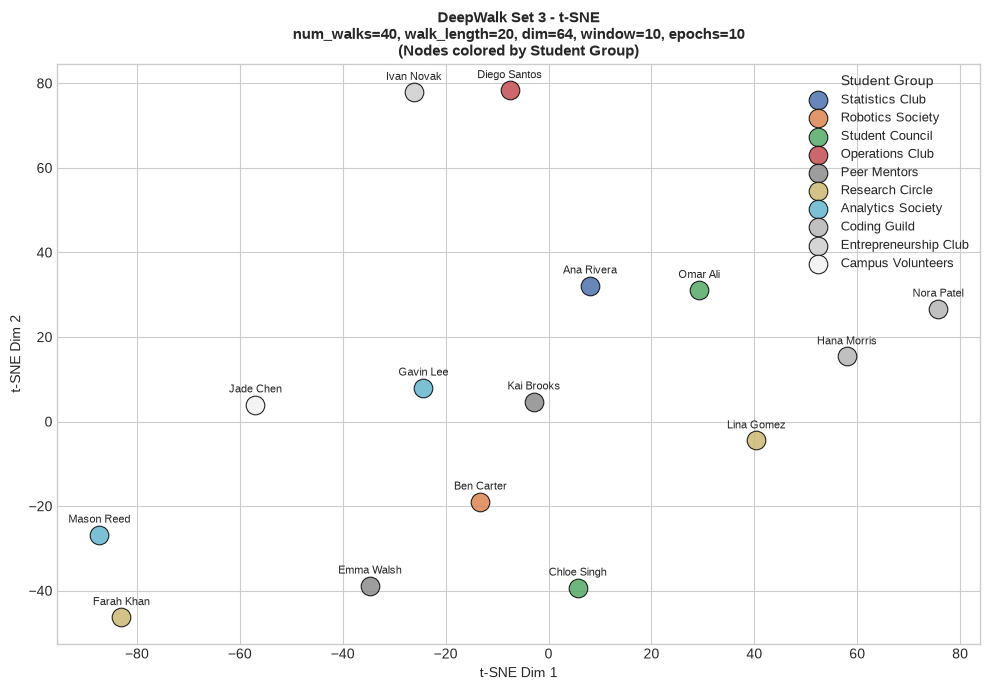

Most similar to Ana Rivera (Set 3):
  Omar Ali   (Business Analytics) - 0.997
  Gavin Lee  (Data Science) - 0.997
  Kai Brooks (Psychology) - 0.996
  Ben Carter (Computer Science) - 0.996
  Diego Santos (Industrial Engineering) - 0.996


In [24]:
DW_PARAMS_3 = dict(num_walks=40, walk_length=20,
                   vector_size=64, window=10, epochs=10)

dw_emb_3, dw_model_3 = train_deepwalk(G, label="DW Set 3", **DW_PARAMS_3)
dw_2d_3 = tsne_project(dw_emb_3, nodes_list)

fig, ax = plt.subplots(figsize=(10, 7))
plot_embedding(ax, dw_2d_3, nodes_list, G, student_group_colors,
               "DeepWalk Set 3 - t-SNE\n"
               f"num_walks={DW_PARAMS_3['num_walks']}, walk_length={DW_PARAMS_3['walk_length']}, "
               f"dim={DW_PARAMS_3['vector_size']}, window={DW_PARAMS_3['window']}, "
               f"epochs={DW_PARAMS_3['epochs']}\n"
               "(Nodes colored by Student Group)")
plt.tight_layout()
plt.savefig('deepwalk_set3.png', dpi=120, bbox_inches='tight')
plt.show()

print("Most similar to Ana Rivera (Set 3):")
for nid, sim in dw_model_3.wv.most_similar('1', topn=5):
    print(f"  {G.nodes[int(nid)]['name']:<10} ({G.nodes[int(nid)]['major']}) - {sim:.3f}")

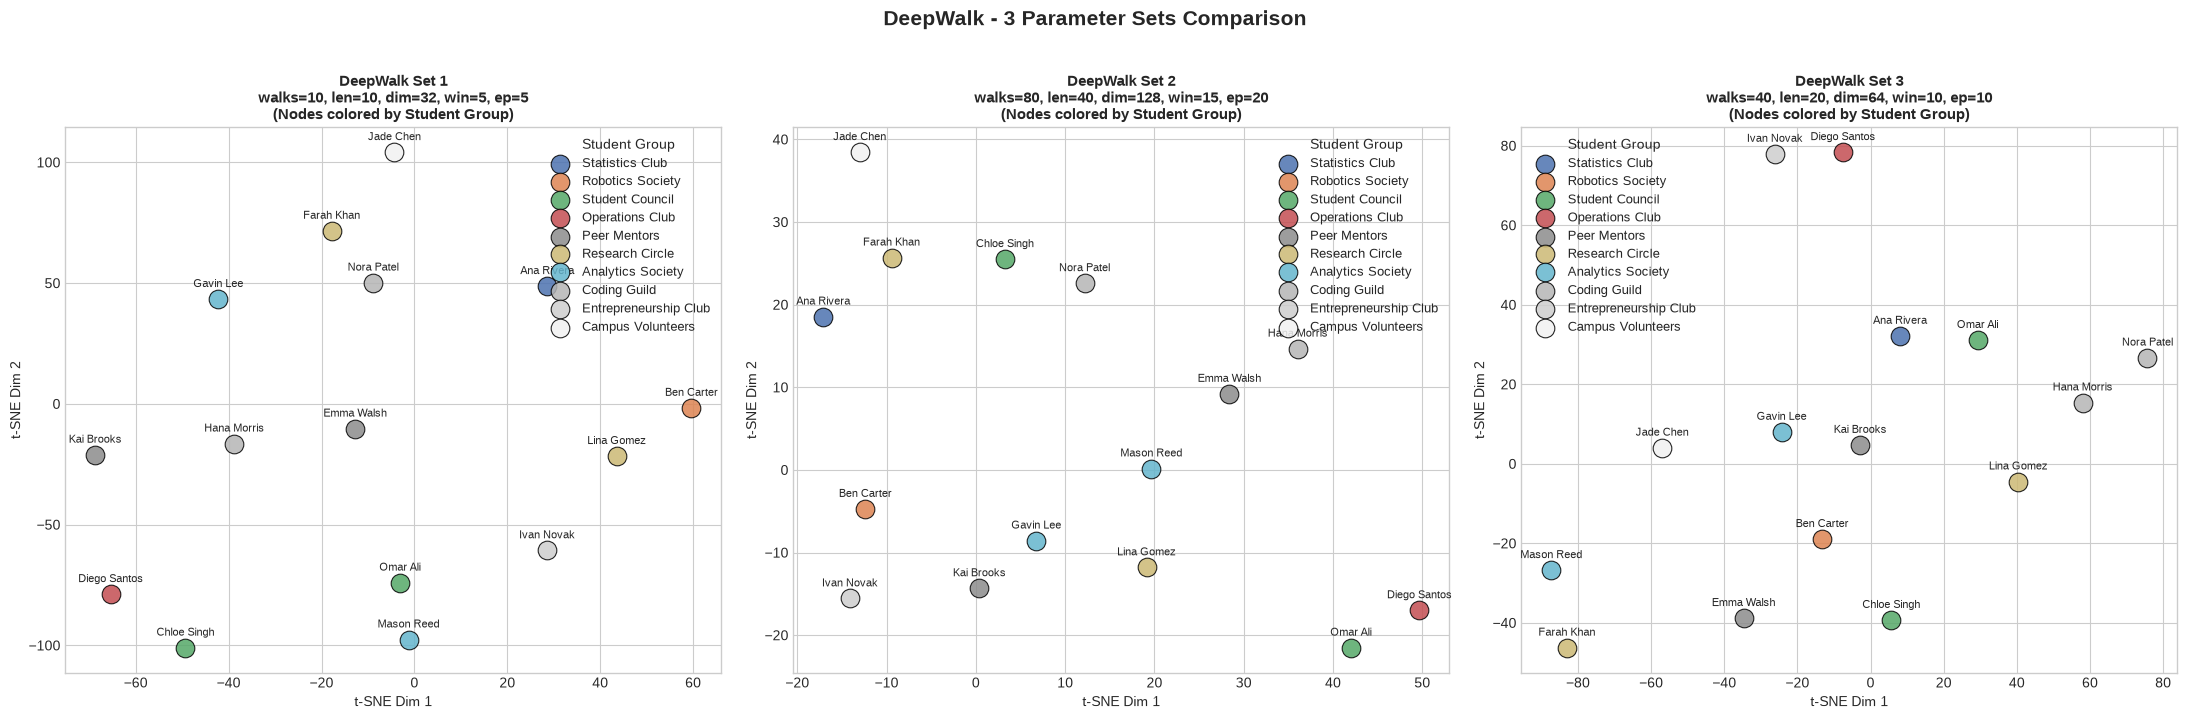

Saved: deepwalk_comparison.png


In [27]:
# DeepWalk: All 3
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

configs = [
    (dw_2d_1, DW_PARAMS_1, "Set 1"),
    (dw_2d_2, DW_PARAMS_2, "Set 2"),
    (dw_2d_3, DW_PARAMS_3, "Set 3"),
]

for ax, (coords, params, label) in zip(axes, configs):
    title = (f"DeepWalk {label}\n"
             f"walks={params['num_walks']}, len={params['walk_length']}, "
             f"dim={params['vector_size']}, win={params['window']}, ep={params['epochs']}\n"
             "(Nodes colored by Student Group)")
    plot_embedding(ax, coords, nodes_list, G, student_group_colors, title)

plt.suptitle('DeepWalk - 3 Parameter Sets Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('deepwalk_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: deepwalk_comparison.png")

# 6. Node2Vec

In [30]:
def train_node2vec(graph, p, q, dimensions, walk_length, num_walks,
                   window, epochs, label="Node2Vec"):
    """Train Node2Vec and return embeddings dict."""
    print(f"[{label}] p={p}, q={q}, dim={dimensions}, "
          f"walk_length={walk_length}, num_walks={num_walks}, "
          f"window={window}, epochs={epochs}")
    n2v = N2V(graph, dimensions=dimensions, walk_length=walk_length,
              num_walks=num_walks, p=p, q=q, workers=1, quiet=True, seed=42)
    model = n2v.fit(window=window, min_count=1, batch_words=4, epochs=epochs, seed=42)
    embeddings = {n: model.wv[str(n)] for n in graph.nodes()}
    print(f"[{label}] Done.\n")
    return embeddings, model

print("Node2Vec helper defined.")

Node2Vec helper defined.


[N2V Set 1] p=2.0, q=4.0, dim=64, walk_length=20, num_walks=40, window=10, epochs=10
[N2V Set 1] Done.



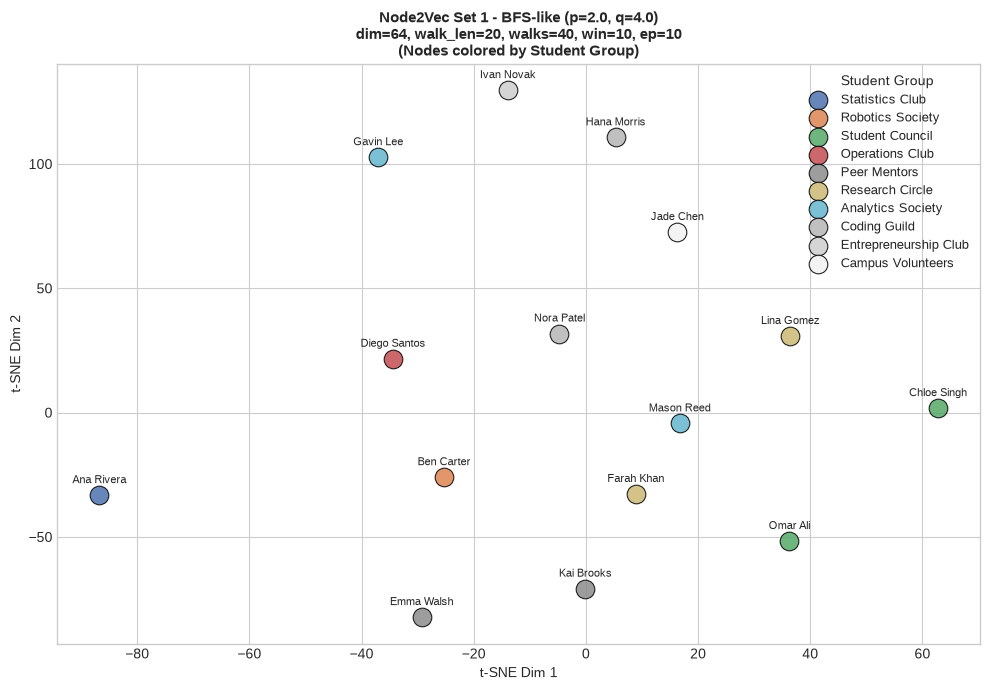

Most similar to Ana Rivera (N2V Set 1):
  Chloe Singh (Business Analytics) - 0.993
  Mason Reed (Data Science) - 0.993
  Omar Ali   (Business Analytics) - 0.993
  Kai Brooks (Psychology) - 0.993
  Lina Gomez (Biology) - 0.993


In [31]:
N2V_PARAMS_1 = dict(p=2.0, q=4.0, dimensions=64, walk_length=20,
                    num_walks=40, window=10, epochs=10)

nv_emb_1, nv_model_1 = train_node2vec(G, label="N2V Set 1", **N2V_PARAMS_1)
nv_2d_1 = tsne_project(nv_emb_1, nodes_list)

fig, ax = plt.subplots(figsize=(10, 7))
plot_embedding(ax, nv_2d_1, nodes_list, G, student_group_colors,
               f"Node2Vec Set 1 - BFS-like (p={N2V_PARAMS_1['p']}, q={N2V_PARAMS_1['q']})\n"
               f"dim={N2V_PARAMS_1['dimensions']}, walk_len={N2V_PARAMS_1['walk_length']}, "
               f"walks={N2V_PARAMS_1['num_walks']}, win={N2V_PARAMS_1['window']}, "
               f"ep={N2V_PARAMS_1['epochs']}\n"
               "(Nodes colored by Student Group)")
plt.tight_layout()
plt.savefig('node2vec_set1.png', dpi=120, bbox_inches='tight')
plt.show()

print("Most similar to Ana Rivera (N2V Set 1):")
for nid, sim in nv_model_1.wv.most_similar('1', topn=5):
    print(f"  {G.nodes[int(nid)]['name']:<10} ({G.nodes[int(nid)]['major']}) - {sim:.3f}")

[N2V Set 1] p=2.0, q=4.0, dim=64, walk_length=20, num_walks=40, window=10, epochs=10
[N2V Set 1] Done.



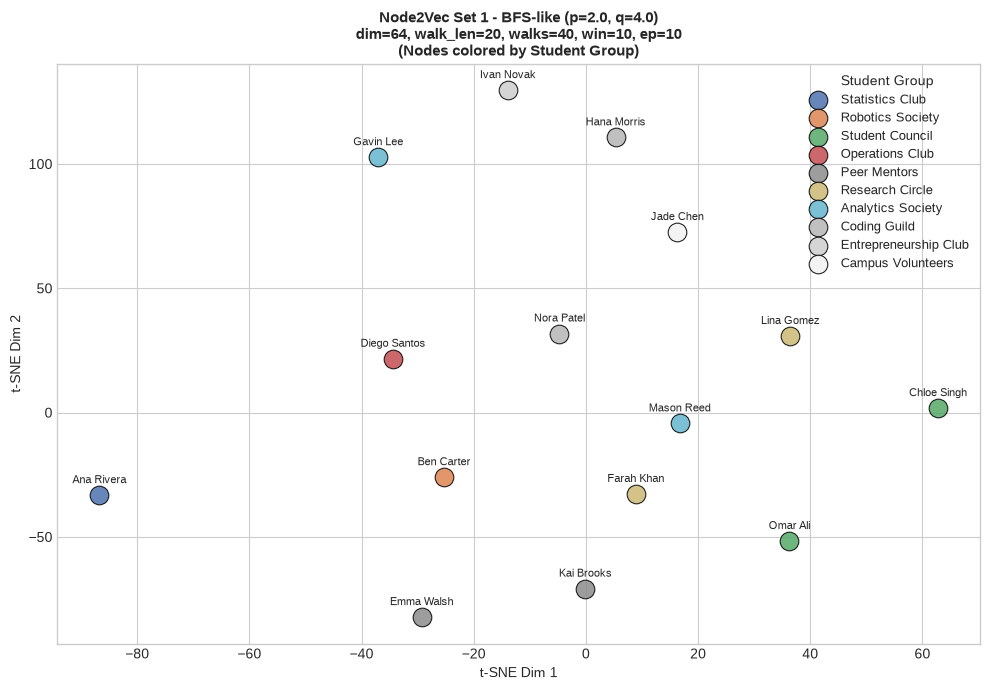

Most similar to Ana Rivera (N2V Set 1):
  Chloe Singh (Business Analytics) - 0.993
  Mason Reed (Data Science) - 0.993
  Omar Ali   (Business Analytics) - 0.993
  Kai Brooks (Psychology) - 0.993
  Lina Gomez (Biology) - 0.993


In [32]:
# ── Node2Vec Set 1: BFS-like (high p, high q) ──────────────────────────────
N2V_PARAMS_1 = dict(p=2.0, q=4.0, dimensions=64, walk_length=20,
                    num_walks=40, window=10, epochs=10)

nv_emb_1, nv_model_1 = train_node2vec(G, label="N2V Set 1", **N2V_PARAMS_1)
nv_2d_1 = tsne_project(nv_emb_1, nodes_list)

fig, ax = plt.subplots(figsize=(10, 7))
plot_embedding(ax, nv_2d_1, nodes_list, G, student_group_colors,
               f"Node2Vec Set 1 - BFS-like (p={N2V_PARAMS_1['p']}, q={N2V_PARAMS_1['q']})\n"
               f"dim={N2V_PARAMS_1['dimensions']}, walk_len={N2V_PARAMS_1['walk_length']}, "
               f"walks={N2V_PARAMS_1['num_walks']}, win={N2V_PARAMS_1['window']}, "
               f"ep={N2V_PARAMS_1['epochs']}\n"
               "(Nodes colored by Student Group)")
plt.tight_layout()
plt.savefig('node2vec_set1.png', dpi=120, bbox_inches='tight')
plt.show()

print("Most similar to Ana Rivera (N2V Set 1):")
for nid, sim in nv_model_1.wv.most_similar('1', topn=5):
    print(f"  {G.nodes[int(nid)]['name']:<10} ({G.nodes[int(nid)]['major']}) - {sim:.3f}")

[N2V Set 2] p=0.25, q=0.25, dim=128, walk_length=30, num_walks=60, window=15, epochs=15
[N2V Set 2] Done.



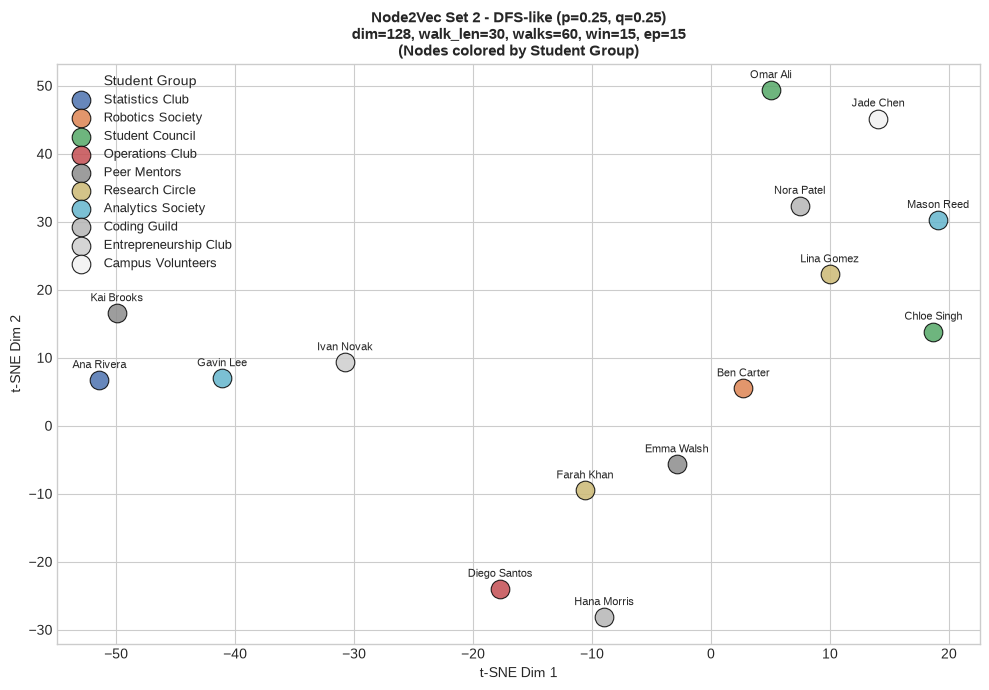

Most similar to Ana Rivera (N2V Set 2):
  Kai Brooks (Psychology) - 0.982
  Gavin Lee  (Data Science) - 0.981
  Ivan Novak (Business Analytics) - 0.964
  Farah Khan (Biology) - 0.937
  Diego Santos (Industrial Engineering) - 0.926


In [33]:
# ── Node2Vec Set 2: DFS-like (low p, low q) ────────────────────────────────
N2V_PARAMS_2 = dict(p=0.25, q=0.25, dimensions=128, walk_length=30,
                    num_walks=60, window=15, epochs=15)

nv_emb_2, nv_model_2 = train_node2vec(G, label="N2V Set 2", **N2V_PARAMS_2)
nv_2d_2 = tsne_project(nv_emb_2, nodes_list)

fig, ax = plt.subplots(figsize=(10, 7))
plot_embedding(ax, nv_2d_2, nodes_list, G, student_group_colors,
               f"Node2Vec Set 2 - DFS-like (p={N2V_PARAMS_2['p']}, q={N2V_PARAMS_2['q']})\n"
               f"dim={N2V_PARAMS_2['dimensions']}, walk_len={N2V_PARAMS_2['walk_length']}, "
               f"walks={N2V_PARAMS_2['num_walks']}, win={N2V_PARAMS_2['window']}, "
               f"ep={N2V_PARAMS_2['epochs']}\n"
               "(Nodes colored by Student Group)")
plt.tight_layout()
plt.savefig('node2vec_set2.png', dpi=120, bbox_inches='tight')
plt.show()

print("Most similar to Ana Rivera (N2V Set 2):")
for nid, sim in nv_model_2.wv.most_similar('1', topn=5):
    print(f"  {G.nodes[int(nid)]['name']:<10} ({G.nodes[int(nid)]['major']}) - {sim:.3f}")

[N2V Set 3 (DeepWalk equiv.)] p=1.0, q=1.0, dim=64, walk_length=20, num_walks=40, window=10, epochs=10
[N2V Set 3 (DeepWalk equiv.)] Done.



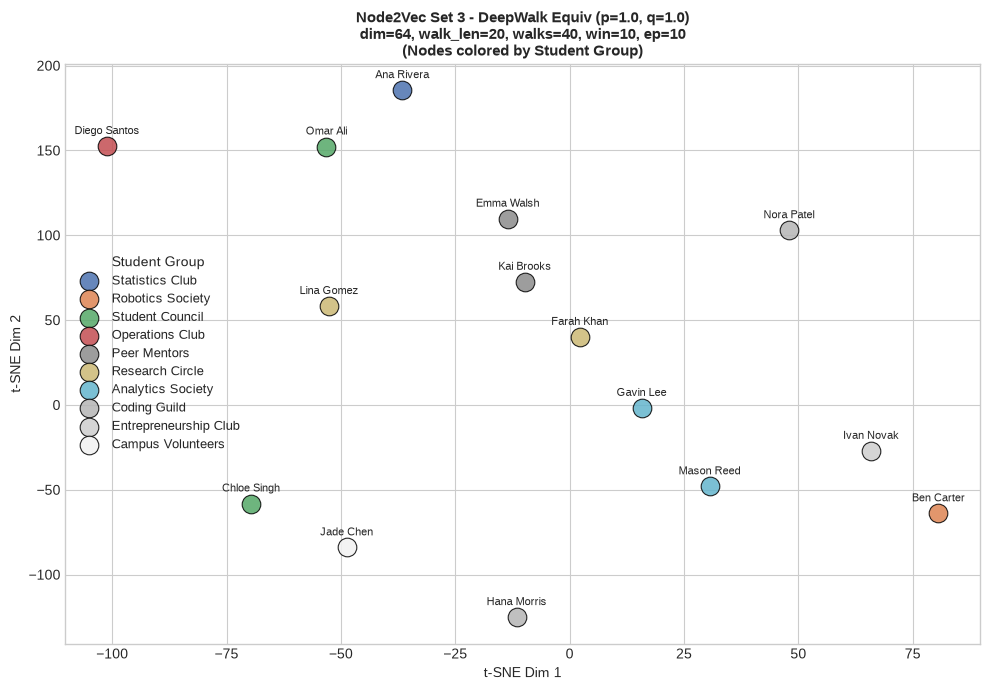

Most similar to Ana Rivera (N2V Set 3):
  Omar Ali   (Business Analytics) - 0.996
  Farah Khan (Biology) - 0.996
  Kai Brooks (Psychology) - 0.996
  Gavin Lee  (Data Science) - 0.995
  Lina Gomez (Biology) - 0.995


In [34]:
# ── Node2Vec Set 3: DeepWalk-equivalent (p=1, q=1) ─────────────────────────
N2V_PARAMS_3 = dict(p=1.0, q=1.0, dimensions=64, walk_length=20,
                    num_walks=40, window=10, epochs=10)

nv_emb_3, nv_model_3 = train_node2vec(G, label="N2V Set 3 (DeepWalk equiv.)", **N2V_PARAMS_3)
nv_2d_3 = tsne_project(nv_emb_3, nodes_list)

fig, ax = plt.subplots(figsize=(10, 7))
plot_embedding(ax, nv_2d_3, nodes_list, G, student_group_colors,
               f"Node2Vec Set 3 - DeepWalk Equiv (p={N2V_PARAMS_3['p']}, q={N2V_PARAMS_3['q']})\n"
               f"dim={N2V_PARAMS_3['dimensions']}, walk_len={N2V_PARAMS_3['walk_length']}, "
               f"walks={N2V_PARAMS_3['num_walks']}, win={N2V_PARAMS_3['window']}, "
               f"ep={N2V_PARAMS_3['epochs']}\n"
               "(Nodes colored by Student Group)")
plt.tight_layout()
plt.savefig('node2vec_set3.png', dpi=120, bbox_inches='tight')
plt.show()

print("Most similar to Ana Rivera (N2V Set 3):")
for nid, sim in nv_model_3.wv.most_similar('1', topn=5):
    print(f"  {G.nodes[int(nid)]['name']:<10} ({G.nodes[int(nid)]['major']}) - {sim:.3f}")

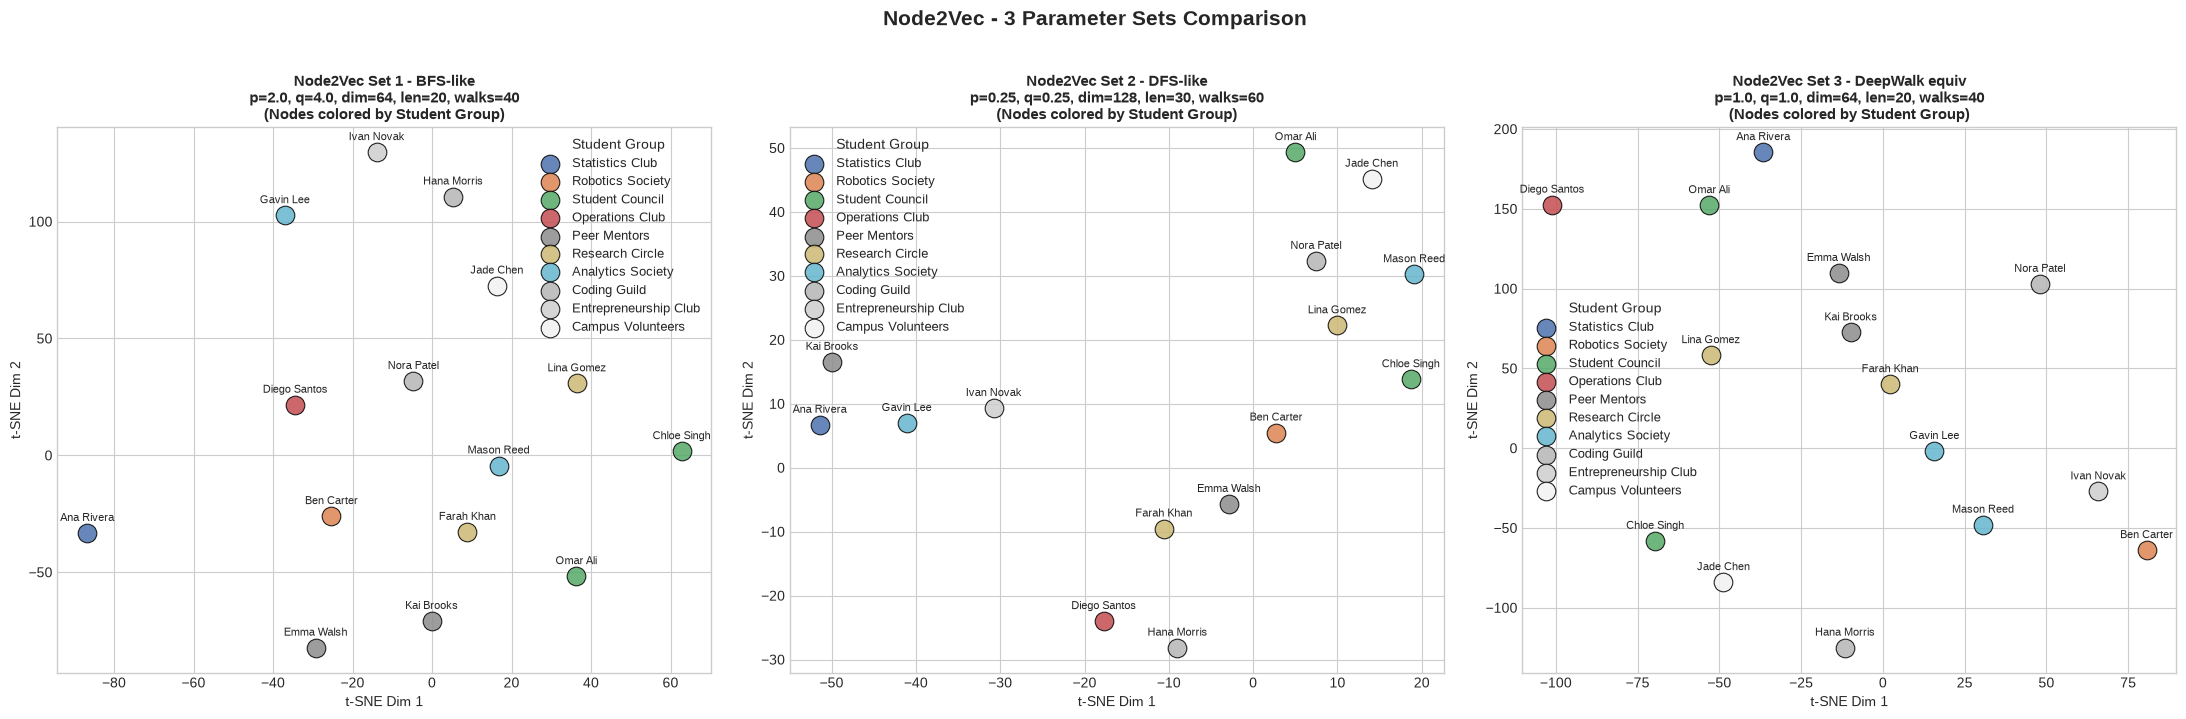

Saved: node2vec_comparison.png


In [35]:
# ── Node2Vec: All 3 Sets Side-by-Side ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

n2v_configs = [
    (nv_2d_1, N2V_PARAMS_1, "Set 1 - BFS-like"),
    (nv_2d_2, N2V_PARAMS_2, "Set 2 - DFS-like"),
    (nv_2d_3, N2V_PARAMS_3, "Set 3 - DeepWalk equiv"),
]

for ax, (coords, params, label) in zip(axes, n2v_configs):
    title = (f"Node2Vec {label}\n"
             f"p={params['p']}, q={params['q']}, dim={params['dimensions']}, "
             f"len={params['walk_length']}, walks={params['num_walks']}\n"
             "(Nodes colored by Student Group)")
    plot_embedding(ax, coords, nodes_list, G, student_group_colors, title)

plt.suptitle('Node2Vec - 3 Parameter Sets Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('node2vec_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: node2vec_comparison.png")